# Prepare real world data and EDA

Task:
- prepare a dataset with the following columns: county, gender, child, adult, senior.
- `county` (string) name should look like `"Albany County"`
- `gender` (category dtype) is categorical variable with two possible values: `"F"` and `"M"`.
- `child` (int64) represents the number of residents in each county under 18 years old
- `adult` (int64) represents the number of residents in each county between 19 to 64 years old
- `senior` (int64) represents the number of residents in each county over 65 years old.

## Read and inspect data

In [1]:
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ny_age = pd.read_csv("data/ACSST5Y2023.S0101-2026-02-23T201031.csv")

ny_age.head()

,Label (Grouping),"Albany County, New York!!Total!!Estimate","Albany County, New York!!Percent!!Estimate","Albany County, New York!!Male!!Estimate","Albany County, New York!!Percent Male!!Estimate","Albany County, New York!!Female!!Estimate","Albany County, New York!!Percent Female!!Estimate","Allegany County, New York!!Total!!Estimate","Allegany County, New York!!Percent!!Estimate","Allegany County, New York!!Male!!Estimate",...,"Wyoming County, New York!!Male!!Estimate","Wyoming County, New York!!Percent Male!!Estimate","Wyoming County, New York!!Female!!Estimate","Wyoming County, New York!!Percent Female!!Estimate","Yates County, New York!!Total!!Estimate","Yates County, New York!!Percent!!Estimate","Yates County, New York!!Male!!Estimate","Yates County, New York!!Percent Male!!Estimate","Yates County, New York!!Female!!Estimate","Yates County, New York!!Percent Female!!Estimate"
0,Total population,"315,374",(X),"153,188",(X),"162,186",(X),"47,027",(X),"23,865",...,"21,429",(X),"18,551",(X),"24,637",(X),"12,084",(X),"12,553",(X)
1,AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Under 5 years,"14,928",4.7%,"7,577",4.9%,"7,351",4.5%,"2,396",5.1%,"1,187",...,905,4.2%,985,5.3%,"1,557",6.3%,839,6.9%,718,5.7%
3,5 to 9 years,"15,626",5.0%,"8,058",5.3%,"7,568",4.7%,"2,425",5.2%,"1,369",...,"1,068",5.0%,"1,039",5.6%,"1,506",6.1%,760,6.3%,746,5.9%
4,10 to 14 years,"16,773",5.3%,"8,581",5.6%,"8,192",5.1%,"2,803",6.0%,"1,323",...,"1,002",4.7%,"1,083",5.8%,"1,657",6.7%,767,6.3%,890,7.1%


In [2]:
ny_age.shape

(42, 373)

In [5]:
ny_age.columns

Index(['Label (Grouping)', 'Albany County, New York!!Total!!Estimate',
       'Albany County, New York!!Percent!!Estimate',
       'Albany County, New York!!Male!!Estimate',
       'Albany County, New York!!Percent Male!!Estimate',
       'Albany County, New York!!Female!!Estimate',
       'Albany County, New York!!Percent Female!!Estimate',
       'Allegany County, New York!!Total!!Estimate',
       'Allegany County, New York!!Percent!!Estimate',
       'Allegany County, New York!!Male!!Estimate',
       ...
       'Wyoming County, New York!!Male!!Estimate',
       'Wyoming County, New York!!Percent Male!!Estimate',
       'Wyoming County, New York!!Female!!Estimate',
       'Wyoming County, New York!!Percent Female!!Estimate',
       'Yates County, New York!!Total!!Estimate',
       'Yates County, New York!!Percent!!Estimate',
       'Yates County, New York!!Male!!Estimate',
       'Yates County, New York!!Percent Male!!Estimate',
       'Yates County, New York!!Female!!Estimate',
  

In [7]:
ny_age.dtypes

Label (Grouping)                                    object
Albany County, New York!!Total!!Estimate            object
Albany County, New York!!Percent!!Estimate          object
Albany County, New York!!Male!!Estimate             object
Albany County, New York!!Percent Male!!Estimate     object
                                                     ...  
Yates County, New York!!Percent!!Estimate           object
Yates County, New York!!Male!!Estimate              object
Yates County, New York!!Percent Male!!Estimate      object
Yates County, New York!!Female!!Estimate            object
Yates County, New York!!Percent Female!!Estimate    object
Length: 373, dtype: object

## Select the columns and rows that may be helpful

- remove all columns with names containing "Percent" or "Total"
- Only select rows: "Total population", "Under 18 years", "65 years and over"
- transpose the dataframe

In [2]:
# Before select, let's remove spaces
ny_age['Label (Grouping)'] = ny_age['Label (Grouping)'].str.strip()

In [8]:
selected_df = ny_age[[col for col in ny_age.columns if "Percent" not in col and "Total" not in col]].copy()
selected_df = selected_df[selected_df['Label (Grouping)'].isin(["Total population", "Under 18 years", "65 years and over"])]

selected_df

,Label (Grouping),"Albany County, New York!!Male!!Estimate","Albany County, New York!!Female!!Estimate","Allegany County, New York!!Male!!Estimate","Allegany County, New York!!Female!!Estimate","Bronx County, New York!!Male!!Estimate","Bronx County, New York!!Female!!Estimate","Broome County, New York!!Male!!Estimate","Broome County, New York!!Female!!Estimate","Cattaraugus County, New York!!Male!!Estimate",...,"Washington County, New York!!Male!!Estimate","Washington County, New York!!Female!!Estimate","Wayne County, New York!!Male!!Estimate","Wayne County, New York!!Female!!Estimate","Westchester County, New York!!Male!!Estimate","Westchester County, New York!!Female!!Estimate","Wyoming County, New York!!Male!!Estimate","Wyoming County, New York!!Female!!Estimate","Yates County, New York!!Male!!Estimate","Yates County, New York!!Female!!Estimate"
0,Total population,"153,188","162,186","23,865","23,162","670,728","748,522","97,684","100,054","38,307",...,"31,286","29,597","45,620","45,508","485,985","510,903","21,429","18,551","12,084","12,553"
23,Under 18 years,"29,296","28,137","4,803","4,541","177,091","170,272","19,658","18,495","8,640",...,"5,864","5,439","9,896","9,435","110,620","104,119","3,667","3,810","2,810","2,816"
31,65 years and over,"24,568","31,564","4,526","4,753","79,363","118,339","17,473","21,900","7,307",...,"6,095","6,623","8,731","9,659","76,339","100,289","3,905","4,031","2,616","2,776"


In [9]:
selected_df = selected_df.T.copy().reset_index()

selected_df

,index,0,23,31
0,Label (Grouping),Total population,Under 18 years,65 years and over
1,"Albany County, New York!!Male!!Estimate","153,188","29,296","24,568"
2,"Albany County, New York!!Female!!Estimate","162,186","28,137","31,564"
3,"Allegany County, New York!!Male!!Estimate","23,865","4,803","4,526"
4,"Allegany County, New York!!Female!!Estimate","23,162","4,541","4,753"
...,...,...,...,...
120,"Westchester County, New York!!Female!!Estimate","510,903","104,119","100,289"
121,"Wyoming County, New York!!Male!!Estimate","21,429","3,667","3,905"
122,"Wyoming County, New York!!Female!!Estimate","18,551","3,810","4,031"
123,"Yates County, New York!!Male!!Estimate","12,084","2,810","2,616"


Inspect the data, we realize the first row should be the column name

In [10]:
selected_df.columns = selected_df.iloc[0]
selected_df = selected_df.iloc[1:].copy()

## Convert the numbers to numeric
- remove the thousand separators first
- Then convert to numeric

In [11]:
for col in selected_df.columns[1:]:
    selected_df[col] = selected_df[col].str.replace(",", "")
    selected_df[col] = pd.to_numeric(selected_df[col], errors="coerce")

In [12]:
selected_df.isna().sum()

0
Label (Grouping)     0
Total population     0
Under 18 years       0
65 years and over    0
dtype: int64

## Edit column names and Ccreate a new column called "adult" and edit other column names

In [13]:
selected_df.rename(columns={'Label (Grouping)': 'county',
                            'Under 18 years': 'child',
                            '65 years and over': 'senior'},
                   inplace=True)

In [14]:
selected_df['adult'] = selected_df['Total population'] - selected_df['child'] - selected_df['senior']

In [15]:
selected_df.drop(columns=['Total population'], inplace=True)

selected_df

,county,child,senior,adult
1,"Albany County, New York!!Male!!Estimate",29296,24568,99324
2,"Albany County, New York!!Female!!Estimate",28137,31564,102485
3,"Allegany County, New York!!Male!!Estimate",4803,4526,14536
4,"Allegany County, New York!!Female!!Estimate",4541,4753,13868
5,"Bronx County, New York!!Male!!Estimate",177091,79363,414274
...,...,...,...,...
120,"Westchester County, New York!!Female!!Estimate",104119,100289,306495
121,"Wyoming County, New York!!Male!!Estimate",3667,3905,13857
122,"Wyoming County, New York!!Female!!Estimate",3810,4031,10710
123,"Yates County, New York!!Male!!Estimate",2810,2616,6658


## Create a new columns called "gender"

In [16]:
selected_df['gender'] = selected_df['county'].apply(lambda x: "M" if "Male" in x else "F")

In [17]:
preferred_col_order = ['county', 'gender', 'child', 'adult','senior']
selected_df = selected_df[preferred_col_order]

## Fixing county names

In [18]:
def extract_county_name(string: str) -> str:
    return string.split(",")[0]

selected_df['county'] = selected_df['county'].apply(extract_county_name)

In [19]:
selected_df.dtypes

0
county    object
gender    object
child      int64
adult      int64
senior     int64
dtype: object

## EDA

In [20]:
selected_df.describe()

,child,adult,senior
count,124.000000,124.000000,124.000000
mean,33139.330645,99208.516129,27912.790323
std,58248.648946,174275.977723,46091.296086
min,326.000000,1372.000000,824.000000
25%,4792.750000,14981.250000,5319.000000
50%,8698.500000,26223.000000,8190.500000
75%,24418.500000,72413.750000,23513.500000
max,304581.000000,864572.000000,230881.000000


In [21]:
print(f"The data contains {selected_df['county'].nunique()} counties.")

The data contains 62 counties.


In [24]:
# create a dataframe with all populations
population_df = selected_df.groupby(by='county', as_index=False).sum().drop(columns='gender').assign(
    total_population = lambda df: df["child"] + df["adult"] + df["senior"]
)

### Population distribution


Text(0.5, 1.0, 'Distribution of total population by county')

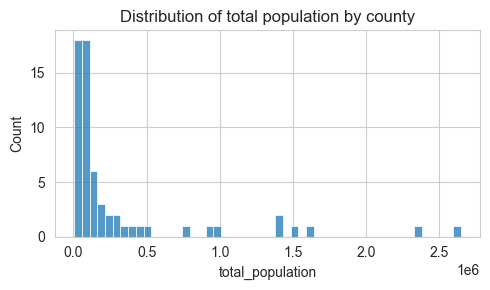

In [29]:
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(5,3), tight_layout=True)

sns.histplot(data=population_df, x="total_population",
             bins=50,
             ax=ax)

plt.title("Distribution of total population by county")

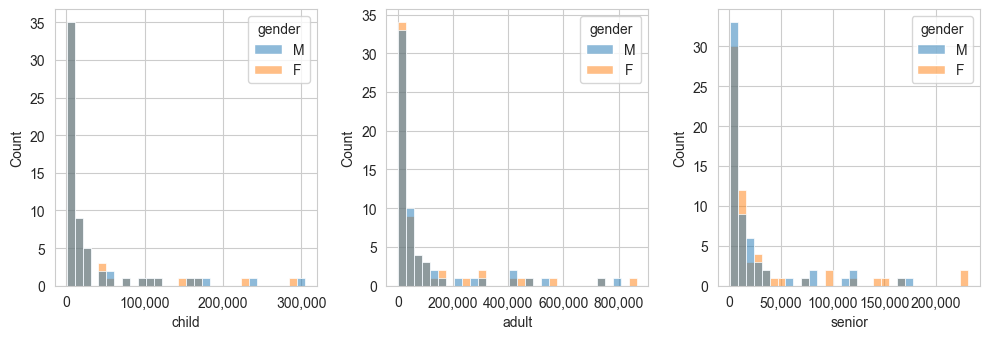

In [47]:
import matplotlib as mpl

fig, axes=plt.subplots(nrows=1, ncols=3, figsize=(10,3.5), tight_layout=True, sharex=False,
                       sharey=False)

for ax, col in zip(axes.flat, ["child", 'adult','senior']):
    sns.histplot(data=selected_df, x=col, hue='gender', bins=30,
                 ax=ax)
    ax.get_xaxis().set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))


Text(0.5, 1.0, 'Distribution of county population by age group and gender')

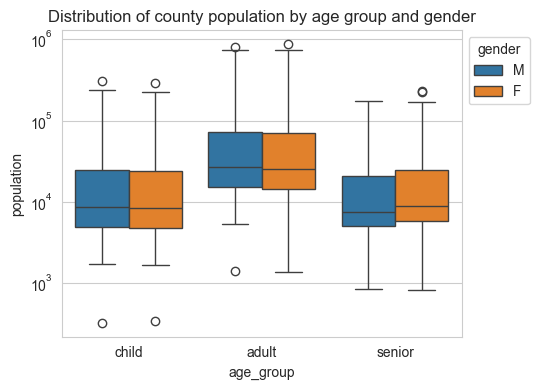

In [54]:
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(5.5, 4), tight_layout=True, sharex=False,
                       sharey=False)

g=sns.boxplot(data=selected_df.melt(id_vars=['county','gender'], value_vars=['child','adult','senior'], var_name='age_group', value_name='population'), x='age_group', y='population', hue='gender', ax=ax, log_scale=True)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.title("Distribution of county population by age group and gender")

62